#📌 Extracción

## 📘 Diccionario de Datos — Telecom X

| Columna | Descripción |
|-------|-------------|
| **customerID** | Número de identificación único de cada cliente. |
| **Churn** | Indica si el cliente dejó o no la empresa. |
| **gender** | Género del cliente (Masculino / Femenino). |
| **SeniorCitizen** | Indica si el cliente tiene **65 años o más**. |
| **Partner** | Indica si el cliente tiene pareja. |
| **Dependents** | Indica si el cliente tiene dependientes. |
| **tenure** | Número de meses que el cliente ha permanecido con la empresa. |
| **PhoneService** | Indica si el cliente tiene servicio telefónico. |
| **MultipleLines** | Indica si el cliente tiene más de una línea telefónica. |
| **InternetService** | Tipo de proveedor de servicio de internet contratado. |
| **OnlineSecurity** | Indica si el cliente tiene servicio adicional de seguridad en línea. |
| **OnlineBackup** | Indica si el cliente tiene servicio adicional de respaldo en línea. |
| **DeviceProtection** | Indica si el cliente tiene protección adicional para su dispositivo. |
| **TechSupport** | Indica si el cliente tiene soporte técnico prioritario (menor tiempo de espera). |
| **StreamingTV** | Indica si el cliente tiene servicio de televisión por streaming. |
| **StreamingMovies** | Indica si el cliente tiene servicio de streaming de películas. |
| **Contract** | Tipo de contrato del cliente. |
| **PaperlessBilling** | Indica si el cliente prefiere recibir la factura de forma electrónica. |
| **PaymentMethod** | Método de pago utilizado por el cliente. |
| **Charges.Monthly** | Total de cargos mensuales por los servicios contratados. |
| **Charges.Total** | Total gastado por el cliente durante todo el tiempo que ha permanecido en la empresa. |


In [26]:

import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json


In [7]:
datos = requests.get('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json')

In [12]:
resultado = json.loads(datos.text)
df = pd.DataFrame(resultado)
df.head()

In [13]:
df = pd.json_normalize(resultado)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [16]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [17]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [18]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [19]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [21]:
df.duplicated().sum()

np.int64(0)

In [23]:
print("\nValores únicos en columnas categóricas:")
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(pd.unique(df[col]))


Valores únicos en columnas categóricas:

customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Churn:
['No' 'Yes' '']

customer.gender:
['Female' 'Male']

customer.Partner:
['Yes' 'No']

customer.Dependents:
['Yes' 'No']

phone.PhoneService:
['Yes' 'No']

phone.MultipleLines:
['No' 'Yes' 'No phone service']

internet.InternetService:
['DSL' 'Fiber optic' 'No']

internet.OnlineSecurity:
['No' 'Yes' 'No internet service']

internet.OnlineBackup:
['Yes' 'No' 'No internet service']

internet.DeviceProtection:
['No' 'Yes' 'No internet service']

internet.TechSupport:
['Yes' 'No' 'No internet service']

internet.StreamingTV:
['Yes' 'No' 'No internet service']

internet.StreamingMovies:
['No' 'Yes' 'No internet service']

account.Contract:
['One year' 'Month-to-month' 'Two year']

account.PaperlessBilling:
['Yes' 'No']

account.PaymentMethod:
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

account.Charges

In [25]:

df["Churn"] = df["Churn"].replace("", np.nan)

print(df["Churn"].isnull().sum())


df = df.dropna(subset=["Churn"])


print("\nDistribución de Churn después de limpieza:")
print(df["Churn"].value_counts())

224

Distribución de Churn después de limpieza:
Churn
no     5174
yes    1869
Name: count, dtype: int64


In [28]:

for col in df.columns:
    if df[col].dtype == "object":
        vacios = (df[col] == "").sum()
        if vacios > 0:
            print(f"{col} tiene {vacios} valores vacíos ('')")

account.Charges.Total tiene 11 valores vacíos ('')


In [31]:

df = df.replace("", np.nan)

print(df.isnull().sum())
df = df.dropna(subset=["account.Charges.Total"])
print(df.isnull().sum())

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
inter

In [32]:
print("\nValores únicos en columnas categóricas:")
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].unique())



Valores únicos en columnas categóricas:

customerID
['0002-orfbo' '0003-mknfe' '0004-tlhlj' ... '9992-ujoel' '9993-lhieb'
 '9995-hotoh']

Churn
['no' 'yes']

customer.gender
['female' 'male']

customer.Partner
['yes' 'no']

customer.Dependents
['yes' 'no']

phone.PhoneService
['yes' 'no']

phone.MultipleLines
['no' 'yes']

internet.InternetService
['dsl' 'fiber optic' 'no']

internet.OnlineSecurity
['no' 'yes']

internet.OnlineBackup
['yes' 'no']

internet.DeviceProtection
['no' 'yes']

internet.TechSupport
['yes' 'no']

internet.StreamingTV
['yes' 'no']

internet.StreamingMovies
['no' 'yes']

account.Contract
['one year' 'month-to-month' 'two year']

account.PaperlessBilling
['yes' 'no']

account.PaymentMethod
['mailed check' 'electronic check' 'credit card (automatic)'
 'bank transfer (automatic)']

account.Charges.Total
['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


In [34]:

df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

df[["account.Charges.Monthly", "Cuentas_Diarias"]].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [36]:

binarias = [
    "Churn", "customer.Partner", "customer.Dependents",
    "phone.PhoneService", "account.PaperlessBilling"
]

for col in binarias:
    if col in df.columns:
        df[col] = df[col].replace({"Yes": 1, "No": 0, "yes": 1, "no": 0})

df = df.rename(columns={
    "customer.gender": "Genero",
    "customer.SeniorCitizen": "Adulto_Mayor",
    "customer.Partner": "Tiene_Pareja",
    "customer.Dependents": "Tiene_Dependientes",
    "customer.tenure": "Meses_Contrato",
    "phone.PhoneService": "Servicio_Telefono",
    "account.Contract": "Tipo_Contrato",
    "account.PaymentMethod": "Metodo_Pago",
    "account.Charges.Monthly": "Cargo_Mensual",
    "account.Charges.Total": "Cargo_Total"
})

df.head()

,customerID,Churn,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-orfbo,0,female,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.6,593.3,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,59.9,542.4,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,83.9,267.4,2.796667


### Carga y analisis


In [37]:
df.describe()

,Churn,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,account.PaperlessBilling,Cargo_Mensual,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.958333


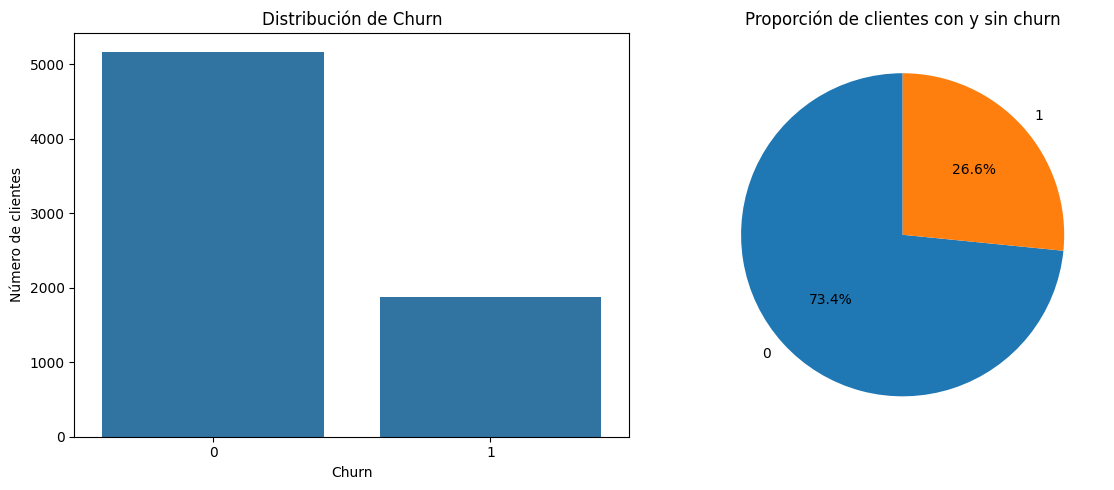

In [38]:

churn_counts = df["Churn"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(12,5))


sns.countplot(x="Churn", data=df, ax=ax[0])
ax[0].set_title("Distribución de Churn")
ax[0].set_xlabel("Churn")
ax[0].set_ylabel("Número de clientes")


ax[1].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%", startangle=90)
ax[1].set_title("Proporción de clientes con y sin churn")

plt.tight_layout()
plt.show()

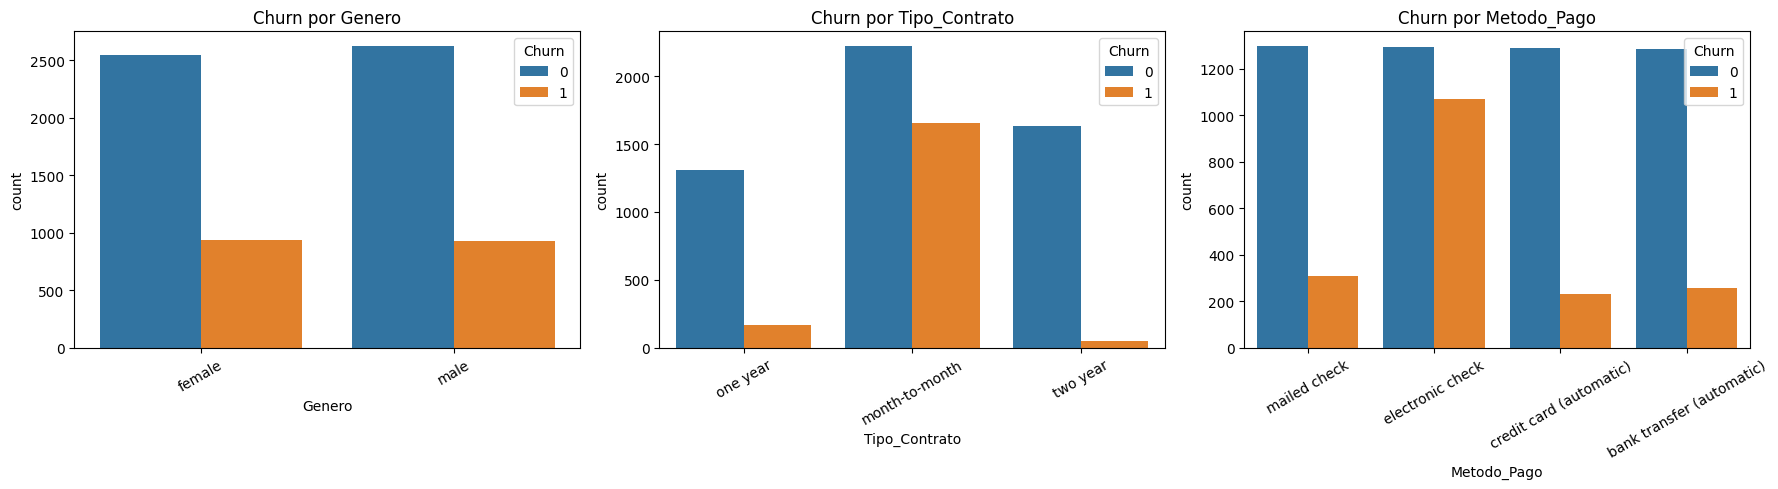

In [41]:
categorical_cols = [
    "Genero",
    "Tipo_Contrato",
    "Metodo_Pago"
]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for col, ax in zip(categorical_cols, axes):
    sns.countplot(data=df, x=col, hue="Churn", ax=ax)
    ax.set_title(f"Churn por {col}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

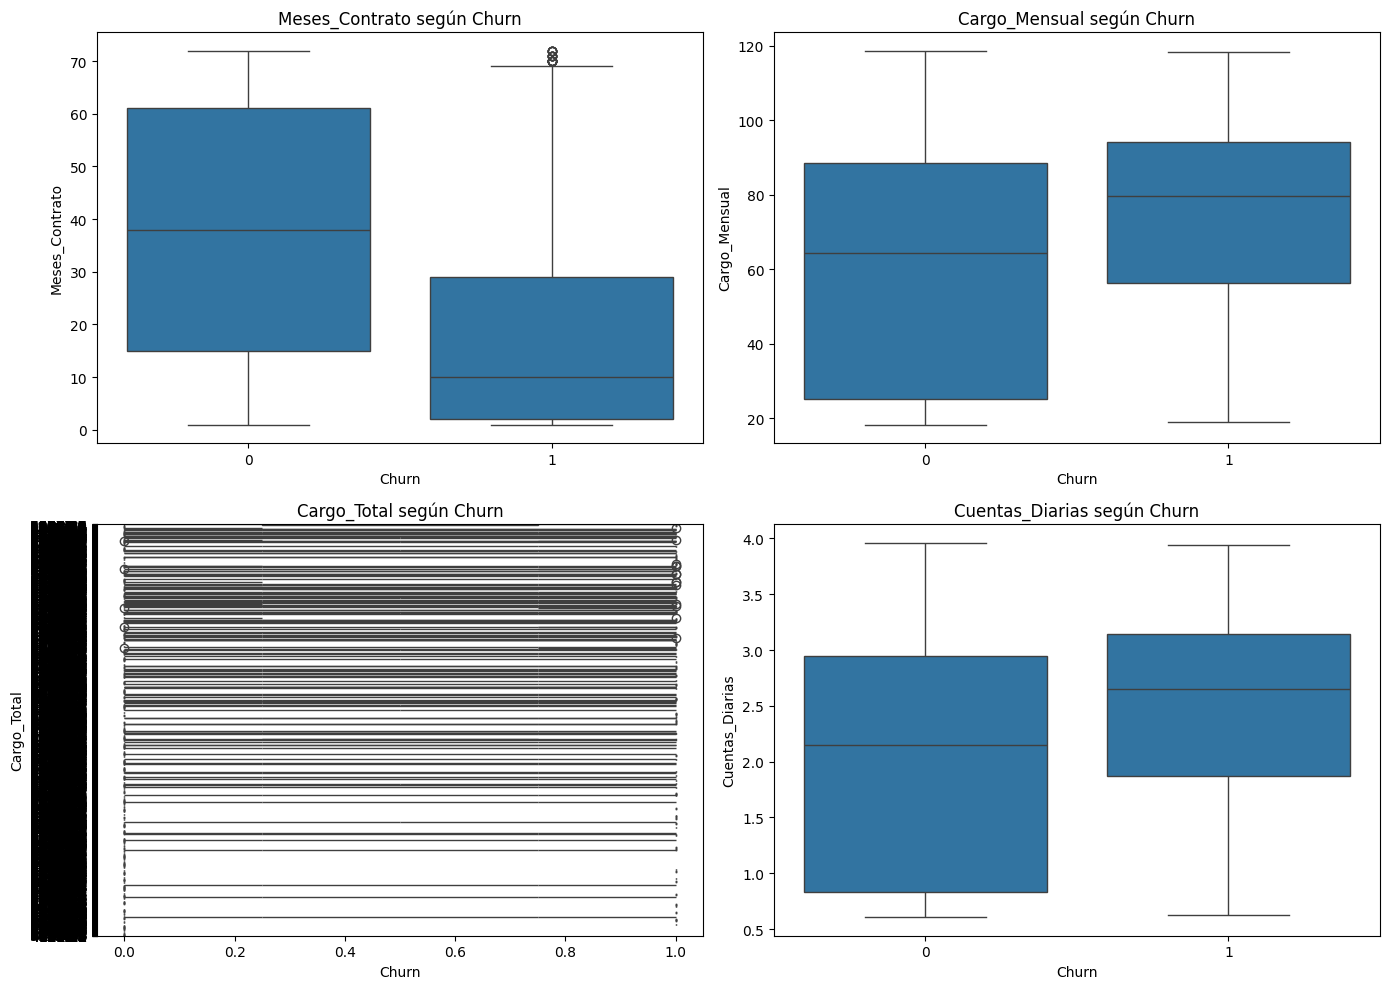

In [42]:
numerical_cols = [
    "Meses_Contrato",
    "Cargo_Mensual",
    "Cuentas_Diarias"
]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for col, ax in zip(numerical_cols, axes.flatten()):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} según Churn")

plt.tight_layout()
plt.show()

#Informe de Análisis de evasión de Clientes (Churn) - Telecom X

El objetivo del análisis realizado fue comprender los factores que influyen en la evasión de clientes (*churn*) en Telecom X. La evasión ocurre cuando un cliente decide cancelar su servicio con la empresa. Este problema es crítico para las empresas de telecomunicaciones, ya que adquirir nuevos clientes suele ser más costoso que retener a los clientes existentes.

A través de este análisis exploratorio de datos, se busca identificar patrones y características comunes entre los clientes que cancelan el servicio, con el fin de proporcionar información útil para estrategias de retención.

##Limpieza y Tratamiento de Datos

Los pasos realizados en el proceso fueron




* Identificación de valores vacíos en la columna **Churn**, representados como `""`, los cuales se transformaron a valores nulos (`NaN`) para su correcto tratamiento.
* Se eliminaron registros sin información en la variable **Churn**, ya que no permiten analizar la evasión.
* Se estandarizaron algunos nombres de columnas para mejorar la claridad del análisis.
* Se creó una nueva variable llamada **Cuentas_Diarias**, calculada a partir de la facturación mensual dividida entre 30, lo que permite analizar el comportamiento de gasto diario de los clientes.


## Análisis Exploratorio de Datos

### Distribución de Churn

Se analizó la proporción de clientes que cancelaron el servicio frente a los que permanecieron. Este análisis permitió observar la magnitud del problema de evasión dentro de la empresa.

### Churn según variables categóricas

Se exploró la relación entre churn y variables categóricas como:

- Género
- Tipo de contrato
- Método de pago

Las visualizaciones mostraron diferencias importantes entre los distintos grupos de clientes.

### Churn según variables numéricas

También se analizaron variables numéricas como:

- Meses de contrato del cliente
- Cargo mensual
- Cargo total
- Cuentas diarias

Los gráficos de distribución y boxplots permitieron observar diferencias en el comportamiento de los clientes que cancelan frente a los que permanecen.



## Conclusiones e Insights

A partir del análisis realizado, se identificaron varios patrones importantes:

- Los clientes con contratos mensuales tienden a cancelar con mayor frecuencia.
- Los clientes con menor tiempo de permanencia (tenure) presentan mayor probabilidad de churn.
- Algunos métodos de pago parecen estar más asociados con la cancelación del servicio, como el cheque electronico.
- Los clientes que tienen transferencias automaticas permanecen mas tiempo
- Los clientes con cargos mensuales más altos muestran una mayor tendencia a abandonar el servicio.



## Recomendaciones

Con base en los hallazgos del análisis, se sugieren las siguientes acciones estratégicas:

- Promover contratos de largo plazo ofreciendo beneficios o descuentos para aumentar la retención.
- Implementar estrategias de fidelización para clientes nuevos, ya que los primeros meses parecen ser críticos para evitar la cancelación.
- Analizar los métodos de pago asociados con mayor churn y ofrecer alternativas más convenientes.
- Revisar la estructura de precios y cargos mensuales, especialmente para clientes con facturación alta.

